<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/blob/main/Week03/doc/Ejercicio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [3]:
!pip install keras tensorflow

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score
from keras.models import Sequential
from keras.layers import Dense

# Implementación de código

In [25]:
# Carga del conjunto de daots Breast Cancer

df = load_breast_cancer()
X = df.data # 569x30
y = df.target # 569x1

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) #[0,1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y entrena el modelo RNA
model = Sequential()
model.add(Dense(10, input_dim=30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred  = (y_pred > 0.5).astype(int)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3714 - loss: 0.7060
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3780 - loss: 0.6745
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4176 - loss: 0.6522
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5121 - loss: 0.6333
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6615 - loss: 0.6170
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7758 - loss: 0.6009 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8484 - loss: 0.5846
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8791 - loss: 0.5675
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8945 - loss: 0.5501
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8989 - loss: 0.5324
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9055 - loss: 0.5143  
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accu

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


# Presentacion de los datos

In [26]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Correlación

In [28]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

Matriz de Confusión: [[40  3]
 [ 1 70]]


Text(0.5, 1.0, 'Matriz de Confusión')

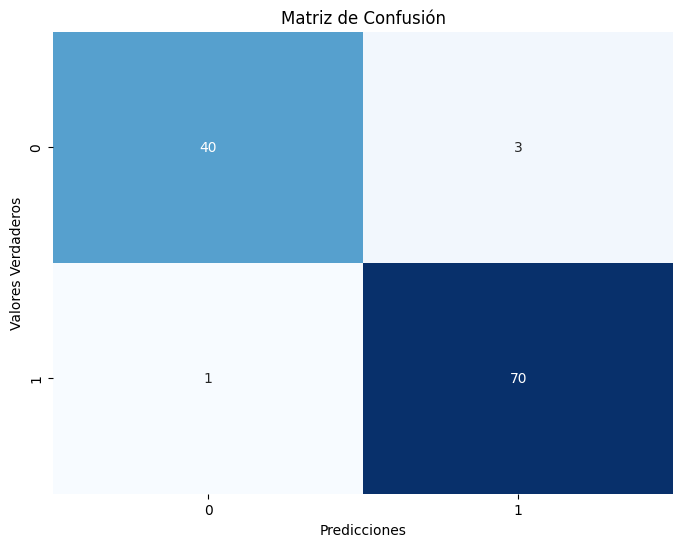

In [29]:
# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

# Métricas

In [37]:
accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.9649122807017544


In [38]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.9859154929577465


In [39]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.958904109589041


In [40]:
# Especificidad

specifity = recall_score(y_test, y_pred , pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.9302325581395349


In [41]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred )
print("Puntuación F1:", f1)

Puntuación F1: 0.9722222222222222


In [42]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred )
print("AUC:", auc)

AUC: 0.9580740255486406


In [43]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred )
print("R2:", R)

R2: 0.8506387160170324


# Gráfico de ROC

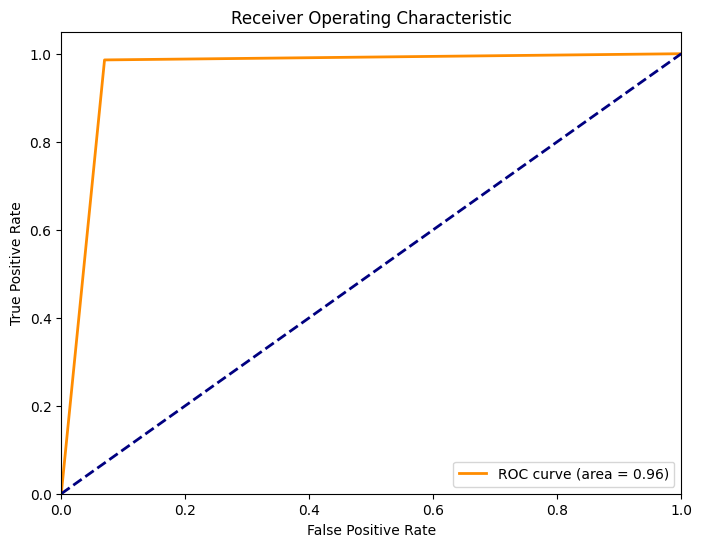

In [44]:
# Gráfico

plt.figure(figsize=(8, 6))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()